## Load in necessary libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os 
from datetime import datetime, timedelta
import fnmatch 
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pytz 
import math
import time
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import xarray
import xarray as xr 
import numpy as np
import glob
import getpass
import act 

# Scikit-learn imports
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Dask imports
from distributed import Client, LocalCluster, progress


# Download data from ARM directly using workflow below

In [ ]:
# Note - recommended ARM Live token to be set as an environmental variable

# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

# Set the datastream and start/enddates
#datastream = 'sgpaoscpcufE13.b1'
datastream = 'sgpaoscpcfE13.b1'

startdate = '2022-12-30'
enddate = '2024-01-02'

# Use ACT to easily download the data.  Watch for the data citation!  Show some support
# for ARM's instrument experts and cite their data if you use it in a publication
arm_files = act.discovery.download_arm_data(arm_username, arm_token, datastream, startdate, enddate)

Enter ARM username:  gcarrillocardenas
Enter ARM token (hidden):  ········


[DOWNLOADING] sgpaoscpcfE13.b1.20221230.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20221231.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230101.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230102.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230103.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230104.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230105.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230106.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230107.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230108.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230109.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230110.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230111.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230112.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230113.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230114.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230115.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230116.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230117.000000.nc
[DOWNLOADING] sgpaoscpcfE13.b1.20230118.000000.nc


In [24]:
path = os.path.expanduser(
    '~/DOE_ARM_SummerSchool/sgpaoscpcufE13.b1/sgpaoscpcufE13.b1*.nc'
)
cpcuf_data_files = sorted(glob.glob(path))
len(cpcuf_data_files)


368

In [26]:
first_file = cpcuf_data_files[0]

ds = xr.open_dataset(first_file)
variables = list(ds.variables)

print(variables)


['base_time', 'time_offset', 'time', 'concentration', 'qc_concentration', 'saturation_temp', 'condensation_temp', 'optics_temp', 'cabinet_temp', 'ambient_pressure', 'orifice_pressure', 'nozzle_pressure', 'laser_current', 'liquid_level', 'fraction_full', 'corrected_flow', 'lat', 'lon', 'alt']


In [27]:
variable_time = ds["time"]

print(variable_time)
print("Name:", variable_time.name)
print("Dimensions:", variable_time.dims)
print("Shape:", variable_time.shape)
print("Data type:", variable_time.dtype)

print("\nAttributes:")


<xarray.DataArray 'time' (time: 86399)>
array(['2022-12-30T00:00:00.950000000', '2022-12-30T00:00:01.950000000',
       '2022-12-30T00:00:02.940000000', ..., '2022-12-30T23:59:57.810000000',
       '2022-12-30T23:59:58.810000000', '2022-12-30T23:59:59.810000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2022-12-30T00:00:00.950000 ... 2022-12-30T...
Attributes:
    long_name:      Time offset from midnight
    standard_name:  time
Name: time
Dimensions: ('time',)
Shape: (86399,)
Data type: datetime64[ns]

Attributes:


In [28]:
variable_concentration = ds["concentration"]

print(variable_concentration)
print("Name:", variable_concentration.name)
print("Dimensions:", variable_concentration.dims)
print("Shape:", variable_concentration.shape)
print("Data type:", variable_concentration.dtype)

print("\nAttributes:")


<xarray.DataArray 'concentration' (time: 86399)>
array([2722.374 , 2703.4688, 2779.0903, ..., 2476.6042, 2542.773 , 2476.6042],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2022-12-30T00:00:00.950000 ... 2022-12-30T...
Attributes:
    long_name:                    Particle concentration
    units:                        1/cm^3
    valid_min:                    5.0
    valid_max:                    50000.0
    corrections_applied:          flow_calibration
    flow_calibration_definition:  The concentration value has been multiplied...
    ancillary_variables:          qc_concentration
Name: concentration
Dimensions: ('time',)
Shape: (86399,)
Data type: float32

Attributes:


In [29]:
cpcuf_ds = xr.open_mfdataset(
    cpcuf_data_files,
    combine="by_coords"
)

# Keep concentration only where qc_concentration == 0
# Usually qc == 0 means good data
# Keep original concentration
# Add QC-fixed concentration as a new xarray variable
cpcuf_ds["concentration_qc_fixed"] = cpcuf_ds["concentration"].where(
    cpcuf_ds["qc_concentration"] == 0
)

# Optional: keep only the variables you care about
cpcuf_ds = cpcuf_ds[
    ["concentration", "qc_concentration", "concentration_qc_fixed"]
]

print(cpcuf_ds)

<xarray.Dataset>
Dimensions:                 (time: 31768745)
Coordinates:
  * time                    (time) datetime64[ns] 2022-12-30T00:00:00.950000 ...
Data variables:
    concentration           (time) float32 dask.array<chunksize=(86399,), meta=np.ndarray>
    qc_concentration        (time) int32 dask.array<chunksize=(86399,), meta=np.ndarray>
    concentration_qc_fixed  (time) float32 dask.array<chunksize=(86399,), meta=np.ndarray>
Attributes: (12/21)
    command_line:                aoscpcufcorr -s sgp -f E13
    Conventions:                 ARM-1.2
    process_version:             ingest-aoscpcufcorr-1.5-0.el7
    dod_version:                 aoscpcuf-b1-4.0
    site_id:                     sgp
    platform_id:                 aoscpcuf
    ...                          ...
    mentor_affiliation:          BNL
    input_datastreams:           sgpaoscpcufE13.a1 : 1.2 : 20221230.000000
    configuration_file:          sgpaoscpcufE13.20190328.160000.config
    AOS_DAC_type:        

In [7]:
#print(cpcuf_ds["concentration"].isel(time=slice(0, 10)).values)
#print(cpcuf_ds["qc_concentration"].isel(time=slice(0, 10)).values)
#print(cpcuf_ds["concentration_qc_fixed"].isel(time=slice(0, 10)).values)

In [30]:
# Select one month
month_ds = cpcuf_ds.sel(
    time=slice("2023-01-01", "2023-02-01")
)

print(month_ds)

<xarray.Dataset>
Dimensions:                 (time: 2764587)
Coordinates:
  * time                    (time) datetime64[ns] 2023-01-01T00:00:00.6799999...
Data variables:
    concentration           (time) float32 dask.array<chunksize=(86400,), meta=np.ndarray>
    qc_concentration        (time) int32 dask.array<chunksize=(86400,), meta=np.ndarray>
    concentration_qc_fixed  (time) float32 dask.array<chunksize=(86400,), meta=np.ndarray>
Attributes: (12/21)
    command_line:                aoscpcufcorr -s sgp -f E13
    Conventions:                 ARM-1.2
    process_version:             ingest-aoscpcufcorr-1.5-0.el7
    dod_version:                 aoscpcuf-b1-4.0
    site_id:                     sgp
    platform_id:                 aoscpcuf
    ...                          ...
    mentor_affiliation:          BNL
    input_datastreams:           sgpaoscpcufE13.a1 : 1.2 : 20221230.000000
    configuration_file:          sgpaoscpcufE13.20190328.160000.config
    AOS_DAC_type:         

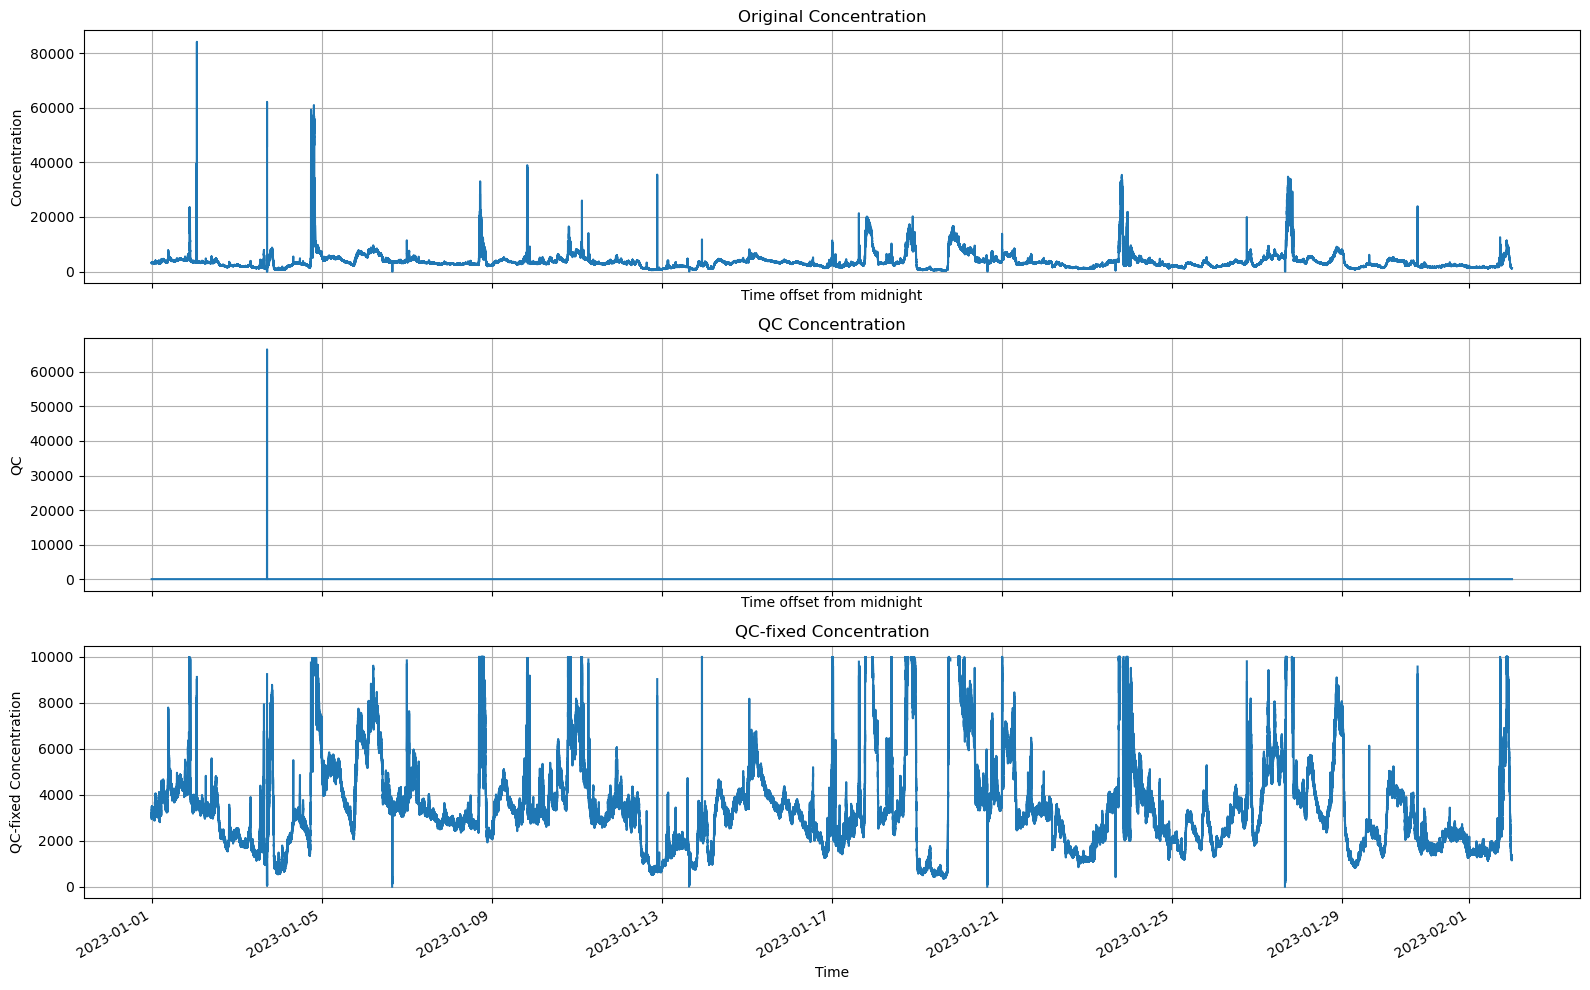

In [31]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 10),
    sharex=True
)

month_ds["concentration"].plot(ax=axes[0])
axes[0].set_title("Original Concentration")
axes[0].set_ylabel("Concentration")

month_ds["qc_concentration"].plot(ax=axes[1])
axes[1].set_title("QC Concentration")
axes[1].set_ylabel("QC")

month_ds["concentration_qc_fixed"].plot(ax=axes[2])
axes[2].set_title("QC-fixed Concentration")
axes[2].set_ylabel("QC-fixed Concentration")
axes[2].set_xlabel("Time")

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()


In [32]:
day_ds = cpcuf_ds.sel(
    time=slice("2023-01-05", "2023-01-07")
)

print(day_ds)

<xarray.Dataset>
Dimensions:                 (time: 259186)
Coordinates:
  * time                    (time) datetime64[ns] 2023-01-05T00:00:00.190000 ...
Data variables:
    concentration           (time) float32 dask.array<chunksize=(86399,), meta=np.ndarray>
    qc_concentration        (time) int32 dask.array<chunksize=(86399,), meta=np.ndarray>
    concentration_qc_fixed  (time) float32 dask.array<chunksize=(86399,), meta=np.ndarray>
Attributes: (12/21)
    command_line:                aoscpcufcorr -s sgp -f E13
    Conventions:                 ARM-1.2
    process_version:             ingest-aoscpcufcorr-1.5-0.el7
    dod_version:                 aoscpcuf-b1-4.0
    site_id:                     sgp
    platform_id:                 aoscpcuf
    ...                          ...
    mentor_affiliation:          BNL
    input_datastreams:           sgpaoscpcufE13.a1 : 1.2 : 20221230.000000
    configuration_file:          sgpaoscpcufE13.20190328.160000.config
    AOS_DAC_type:          

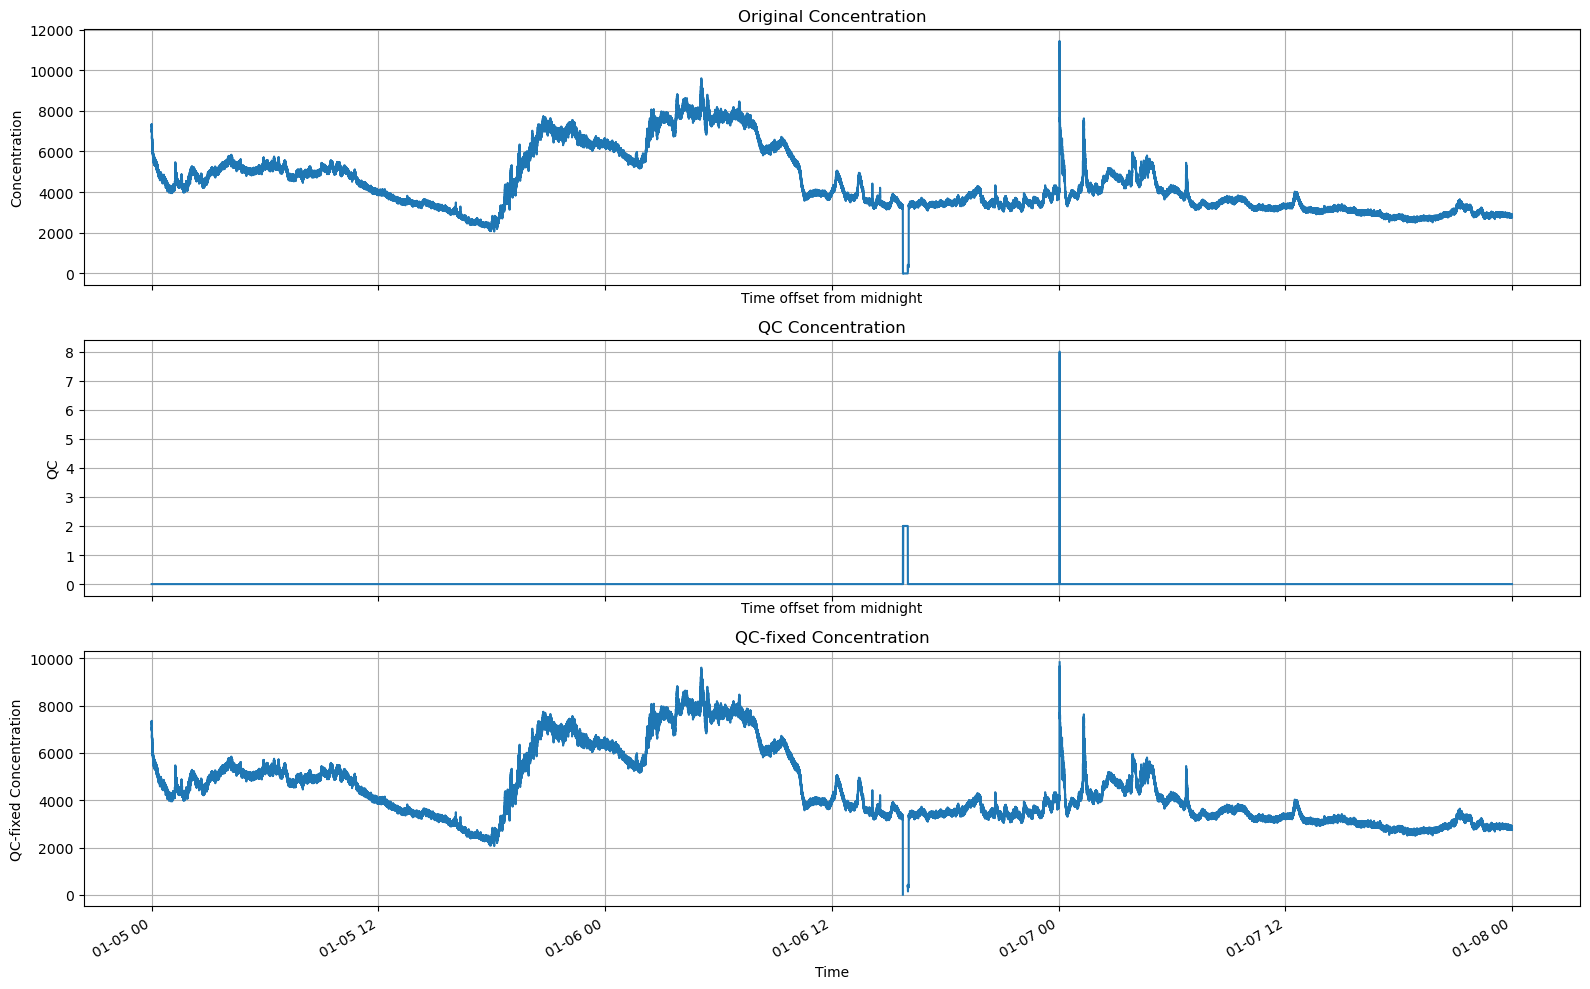

In [33]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 10),
    sharex=True
)

day_ds["concentration"].plot(ax=axes[0])
axes[0].set_title("Original Concentration")
axes[0].set_ylabel("Concentration")

day_ds["qc_concentration"].plot(ax=axes[1])
axes[1].set_title("QC Concentration")
axes[1].set_ylabel("QC")

day_ds["concentration_qc_fixed"].plot(ax=axes[2])
axes[2].set_title("QC-fixed Concentration")
axes[2].set_ylabel("QC-fixed Concentration")
axes[2].set_xlabel("Time")

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

In [34]:
cpcuf_ds["time_Local"] = cpcuf_ds["time"] - pd.Timedelta(hours=6)
cpcuf_ds["time_Local"].attrs["note"] = "UTC time minus 6 hours"

In [35]:
print(cpcuf_ds["time"].isel(time=slice(0, 5)).values)
print(cpcuf_ds["time_Local"].isel(time=slice(0, 5)).values)

['2022-12-30T00:00:00.950000000' '2022-12-30T00:00:01.950000000'
 '2022-12-30T00:00:02.940000000' '2022-12-30T00:00:03.950000000'
 '2022-12-30T00:00:04.950000000']
['2022-12-29T18:00:00.950000000' '2022-12-29T18:00:01.950000000'
 '2022-12-29T18:00:02.940000000' '2022-12-29T18:00:03.950000000'
 '2022-12-29T18:00:04.950000000']


In [36]:
print(cpcuf_ds["time_Local"].attrs)


{'note': 'UTC time minus 6 hours'}


In [37]:
path = os.path.expanduser(
    '~/DOE_ARM_SummerSchool/sgpaoscpcfE13.b1/sgpaoscpcfE13.b1*.nc'
)
cpcFINE_data_files = sorted(glob.glob(path))  

cpcFINE_ds = xr.open_mfdataset(
    cpcFINE_data_files,
    combine="by_coords"
)

# Keep concentration only where qc_concentration == 0
# Usually qc == 0 means good data
# Keep original concentration
# Add QC-fixed concentration as a new xarray variable
cpcFINE_ds["concentration_qc_fixed"] = cpcFINE_ds["concentration"].where(
    cpcFINE_ds["qc_concentration"] == 0
)

# Optional: keep only the variables you care about
cpcFINE_ds = cpcFINE_ds[
    ["concentration", "qc_concentration", "concentration_qc_fixed"]
]

print(cpcFINE_ds)

<xarray.Dataset>
Dimensions:                 (time: 31764571)
Coordinates:
  * time                    (time) datetime64[ns] 2022-12-30T00:00:00.950000 ...
Data variables:
    concentration           (time) float32 dask.array<chunksize=(86399,), meta=np.ndarray>
    qc_concentration        (time) int32 dask.array<chunksize=(86399,), meta=np.ndarray>
    concentration_qc_fixed  (time) float32 dask.array<chunksize=(86399,), meta=np.ndarray>
Attributes: (12/21)
    command_line:                aoscpcfcorr -s sgp -f E13 -b 20221205 -e 202...
    Conventions:                 ARM-1.2
    process_version:             ingest-aoscpcfcorr-2.7-0.el7
    dod_version:                 aoscpcf-b1-4.0
    site_id:                     sgp
    platform_id:                 aoscpcf
    ...                          ...
    mentor_affiliation:          BNL
    input_datastreams:           sgpaoscpcfE13.a1 : 1.1 : 20221230.000000
    configuration_file:          sgpaoscpcfE13.20190328.160000.config
    AOS_D

In [11]:
cpcFINE_ds["time_Local"] = cpcFINE_ds["time"] - pd.Timedelta(hours=6)
cpcFINE_ds["time_Local"].attrs["note"] = "UTC time minus 6 hours"

In [21]:
print(cpcFINE_ds["time"].isel(time=slice(0, 5)).values)
print(cpcFINE_ds["time_Local"].isel(time=slice(0, 5)).values)

['2022-12-30T00:00:00.950000000' '2022-12-30T00:00:01.960000000'
 '2022-12-30T00:00:02.950000000' '2022-12-30T00:00:03.950000000'
 '2022-12-30T00:00:04.950000000']
['2022-12-29T18:00:00.950000000' '2022-12-29T18:00:01.960000000'
 '2022-12-29T18:00:02.950000000' '2022-12-29T18:00:03.950000000'
 '2022-12-29T18:00:04.950000000']


In [12]:
cpcFINE_local = cpcFINE_ds.swap_dims({"time": "time_Local"})
cpcuf_local = cpcuf_ds.swap_dims({"time": "time_Local"})

In [13]:
cpcFINE_local = cpcFINE_local.rename({
    "concentration": "concentration_FINE",
    "concentration_qc_fixed": "concentration_FINE_qc_fixed",
    "qc_concentration": "qc_concentration_FINE"
})
cpcFINE_local_clean = (
    cpcFINE_local[["concentration_FINE_qc_fixed"]]
    .drop_vars(["time"], errors="ignore")
)

cpcuf_local = cpcuf_local.rename({
    "concentration": "concentration_UF",
    "qc_concentration": "qc_concentration_UF",
    "concentration_qc_fixed": "concentration_UF_qc_fixed"
})

cpcuf_local_clean = (
    cpcuf_local[["concentration_UF_qc_fixed"]]
    .drop_vars(["time"], errors="ignore")
)



In [15]:
# 5-minute averages for each dataset
cpcFINE_merge = cpcFINE_local_clean.resample(time_Local="5min").mean()
cpcuf_merge = cpcuf_local_clean.resample(time_Local="5min").mean()


In [16]:
print("all done")

all done


In [17]:
fine_times = cpcFINE_merge["time_Local"].isel(time_Local=slice(0, 5)).values
uf_times = cpcuf_merge["time_Local"].isel(time_Local=slice(0, 5)).values

for i, (fine_t, uf_t) in enumerate(zip(fine_times, uf_times)):
    print(i, "FINE:", fine_t, "| UF:", uf_t)

0 FINE: 2022-12-29T18:00:00.000000000 | UF: 2022-12-29T18:00:00.000000000
1 FINE: 2022-12-29T18:05:00.000000000 | UF: 2022-12-29T18:05:00.000000000
2 FINE: 2022-12-29T18:10:00.000000000 | UF: 2022-12-29T18:10:00.000000000
3 FINE: 2022-12-29T18:15:00.000000000 | UF: 2022-12-29T18:15:00.000000000
4 FINE: 2022-12-29T18:20:00.000000000 | UF: 2022-12-29T18:20:00.000000000


In [ ]:
#day_merge = cpcuf_merge.sel(
#    time_Local=slice("2023-01-05", "2023-01-05")
#)

#print(day_merge)

In [151]:
#day_merge

<xarray.Dataset> Size: 3kB
Dimensions:                    (time_Local: 288)
Coordinates:
  * time_Local                 (time_Local) datetime64[ns] 2kB 2023-01-05 ......
Data variables:
    concentration_UF_qc_fixed  (time_Local) float32 1kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/21)
    command_line:                aoscpcufcorr -s sgp -f E13
    Conventions:                 ARM-1.2
    process_version:             ingest-aoscpcufcorr-1.5-0.el7
    dod_version:                 aoscpcuf-b1-4.0
    site_id:                     sgp
    platform_id:                 aoscpcuf
    ...                          ...
    mentor_affiliation:          BNL
    input_datastreams:           sgpaoscpcufE13.a1 : 1.2 : 20221230.000000
    configuration_file:          sgpaoscpcufE13.20190328.160000.config
    AOS_DAC_type:                D
    doi:                         10.5439/1378933
    history:                     created by user dsmgr on machine prod-proc3....

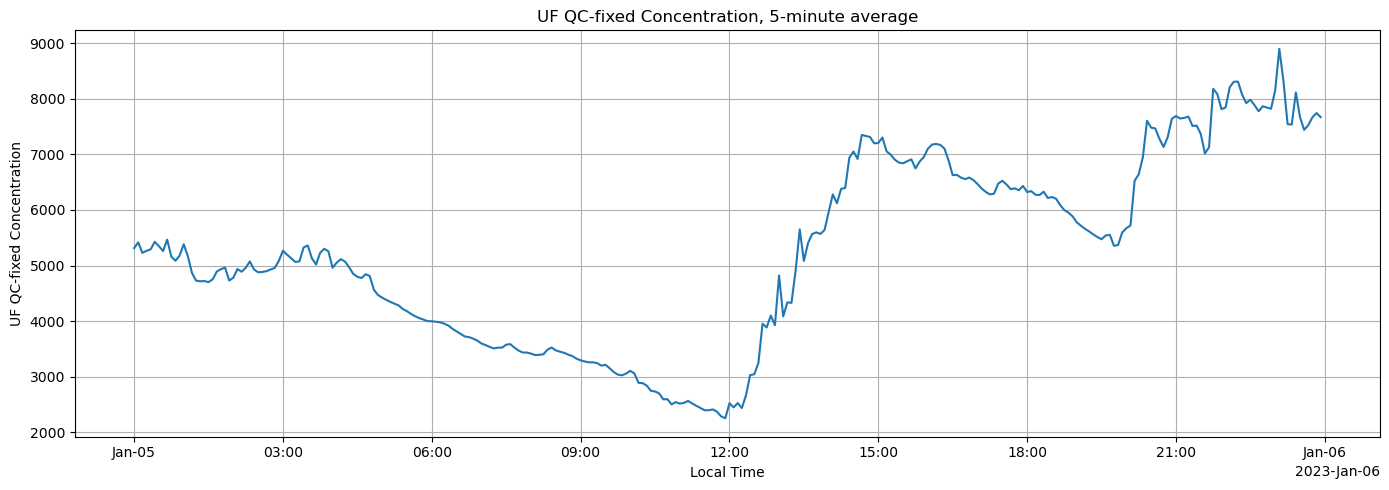

In [152]:
#plt.figure(figsize=(14, 5))

#day_merge["concentration_UF_qc_fixed"].plot()

#plt.xlabel("Local Time")
#plt.ylabel("UF QC-fixed Concentration")
#plt.title("UF QC-fixed Concentration, 5-minute average")
#plt.grid(True)
#plt.tight_layout()
#plt.show()

In [18]:
merged_cpc_5min = xr.merge(
    [cpcFINE_merge, cpcuf_merge],
    join="inner"
)

print(merged_cpc_5min)

<xarray.Dataset>
Dimensions:                      (time_Local: 105984)
Coordinates:
  * time_Local                   (time_Local) datetime64[ns] 2022-12-29T18:00...
Data variables:
    concentration_FINE_qc_fixed  (time_Local) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    concentration_UF_qc_fixed    (time_Local) float32 dask.array<chunksize=(1,), meta=np.ndarray>


In [19]:
merged_cpc_5min["UF_minus_FINE"] = (
    merged_cpc_5min["concentration_UF_qc_fixed"]
    - merged_cpc_5min["concentration_FINE_qc_fixed"]
)


In [20]:
merged_cpc_2023 = merged_cpc_5min.sel(
    time_Local=slice("2023-01-01", "2024-01-01")
)

print(merged_cpc_2023)

<xarray.Dataset>
Dimensions:                      (time_Local: 105336)
Coordinates:
  * time_Local                   (time_Local) datetime64[ns] 2023-01-01 ... 2...
Data variables:
    concentration_FINE_qc_fixed  (time_Local) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    concentration_UF_qc_fixed    (time_Local) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    UF_minus_FINE                (time_Local) float32 dask.array<chunksize=(1,), meta=np.ndarray>


In [21]:

merged_cpc_2023_df = (
    merged_cpc_2023[["UF_minus_FINE"]]
    .chunk({"time_Local": -1})
    .compute()
    .to_dataframe()
    .reset_index()
)

In [22]:
merged_cpc_2023_df.to_csv("merged_cpc_2023_UF_minus_FINE5min.csv", index=False)